# Improved CNN and Model Comparison

## Facial Emotion Recognition on FER2013

This notebook documents the **Improved CNN** experiments and compares them with the previously trained Baseline CNN.

Unlike the baseline stage, this stage includes multiple experiments:

1. **Baseline CNN**
2. **Improved CNN with class weights**
3. **Improved CNN without class weights**

The purpose is not only to find the highest accuracy, but also to understand the trade-offs between accuracy, Macro F1-score, Weighted F1-score, class imbalance handling, and confusion matrix behavior.

## 1. Import Required Libraries

This notebook reads outputs generated by the training, evaluation, and comparison scripts. It does not retrain any model.

In [1]:
from pathlib import Path
import json

from IPython.display import Image, display
import pandas as pd

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Detect Project Paths

The following cell works whether the notebook is launched from the project root directory or from the `notebooks/` directory.

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == 'notebooks':
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'

print(f'Project root: {PROJECT_ROOT}')
print(f'Models directory: {MODELS_DIR}')
print(f'Figures directory: {FIGURES_DIR}')
print(f'Metrics directory: {METRICS_DIR}')

Project root: d:\projects\facial-emotion-recognition
Models directory: d:\projects\facial-emotion-recognition\models
Figures directory: d:\projects\facial-emotion-recognition\outputs\figures
Metrics directory: d:\projects\facial-emotion-recognition\outputs\metrics


## 3. Required Files Check

Before analyzing the results, we verify that all required files exist.

In [3]:
required_files = {
    'Baseline test metrics': METRICS_DIR / 'baseline_cnn_test_metrics.json',
    'Improved test metrics': METRICS_DIR / 'improved_cnn_test_metrics.json',
    'Improved no class weights test metrics': METRICS_DIR / 'improved_cnn_no_class_weights_test_metrics.json',
    'Model comparison CSV': METRICS_DIR / 'model_comparison.csv',
    'Model comparison JSON': METRICS_DIR / 'model_comparison.json',
    'Improved history': METRICS_DIR / 'improved_cnn_history.csv',
    'Improved no class weights history': METRICS_DIR / 'improved_cnn_no_class_weights_history.csv',
    'Improved validation results': METRICS_DIR / 'improved_cnn_validation_results.json',
    'Improved no class weights validation results': METRICS_DIR / 'improved_cnn_no_class_weights_validation_results.json',
    'Improved classification report': METRICS_DIR / 'improved_cnn_classification_report.txt',
    'Improved no class weights classification report': METRICS_DIR / 'improved_cnn_no_class_weights_classification_report.txt',
    'Improved accuracy curve': FIGURES_DIR / 'improved_cnn_accuracy_curve.png',
    'Improved loss curve': FIGURES_DIR / 'improved_cnn_loss_curve.png',
    'Improved no class weights accuracy curve': FIGURES_DIR / 'improved_cnn_no_class_weights_accuracy_curve.png',
    'Improved no class weights loss curve': FIGURES_DIR / 'improved_cnn_no_class_weights_loss_curve.png',
    'Improved confusion matrix': FIGURES_DIR / 'improved_cnn_confusion_matrix.png',
    'Improved no class weights confusion matrix': FIGURES_DIR / 'improved_cnn_no_class_weights_confusion_matrix.png',
    'Model comparison chart': FIGURES_DIR / 'model_comparison_metrics.png',
}

file_check = pd.DataFrame({
    'File': list(required_files.keys()),
    'Path': [str(path) for path in required_files.values()],
    'Exists': [path.exists() for path in required_files.values()],
})

display(file_check)

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    print('Missing files:')
    for item in missing_files:
        print(f'- {item}')
    raise FileNotFoundError('Some required output files are missing. Run the improved training/evaluation and comparison scripts first.')
else:
    print('All required files are available.')

,File,Path,Exists
0,Baseline test metrics,d:\projects\facial-emotion-recognition\outputs...,True
1,Improved test metrics,d:\projects\facial-emotion-recognition\outputs...,True
2,Improved no class weights test metrics,d:\projects\facial-emotion-recognition\outputs...,True
3,Model comparison CSV,d:\projects\facial-emotion-recognition\outputs...,True
4,Model comparison JSON,d:\projects\facial-emotion-recognition\outputs...,True
5,Improved history,d:\projects\facial-emotion-recognition\outputs...,True
6,Improved no class weights history,d:\projects\facial-emotion-recognition\outputs...,True
7,Improved validation results,d:\projects\facial-emotion-recognition\outputs...,True
8,Improved no class weights validation results,d:\projects\facial-emotion-recognition\outputs...,True
9,Improved classification report,d:\projects\facial-emotion-recognition\outputs...,True


All required files are available.


## 4. Experiment Overview

Three model configurations are compared in this stage.

| Experiment | Architecture | Data Augmentation | Batch Normalization | Class Weights |
|---|---|---:|---:|---:|
| Baseline CNN | Simple CNN | No | No | No |
| Improved CNN + Class Weights | Deeper CNN | Yes | Yes | Yes |
| Improved CNN No Class Weights | Deeper CNN | Yes | Yes | No |

The improved architecture uses data augmentation, batch normalization, deeper convolutional blocks, global average pooling, and dropout regularization.

## 5. Load Model Comparison Table

The comparison table summarizes the final test-set metrics for all trained models.

In [4]:
comparison_path = METRICS_DIR / 'model_comparison.csv'
comparison = pd.read_csv(comparison_path)

numeric_columns = [
    'Test Accuracy',
    'Macro Precision',
    'Macro Recall',
    'Macro F1',
    'Weighted F1',
    'Test Loss',
]

display(comparison)

rounded_comparison = comparison.copy()
rounded_comparison[numeric_columns] = rounded_comparison[numeric_columns].round(4)
display(rounded_comparison)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Test Loss
0,Baseline CNN,0.588186,0.591218,0.521086,0.530373,0.573055,1.106709
1,Improved CNN + Class Weights,0.525216,0.443988,0.489597,0.443908,0.494774,1.212756
2,Improved CNN No Class Weights,0.597660,0.485471,0.502719,0.486959,0.581135,1.063637


,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Test Loss
0,Baseline CNN,0.5882,0.5912,0.5211,0.5304,0.5731,1.1067
1,Improved CNN + Class Weights,0.5252,0.4440,0.4896,0.4439,0.4948,1.2128
2,Improved CNN No Class Weights,0.5977,0.4855,0.5027,0.4870,0.5811,1.0636


## 6. Main Model Comparison Chart

This chart compares the most important evaluation metrics: Test Accuracy, Macro F1, and Weighted F1.

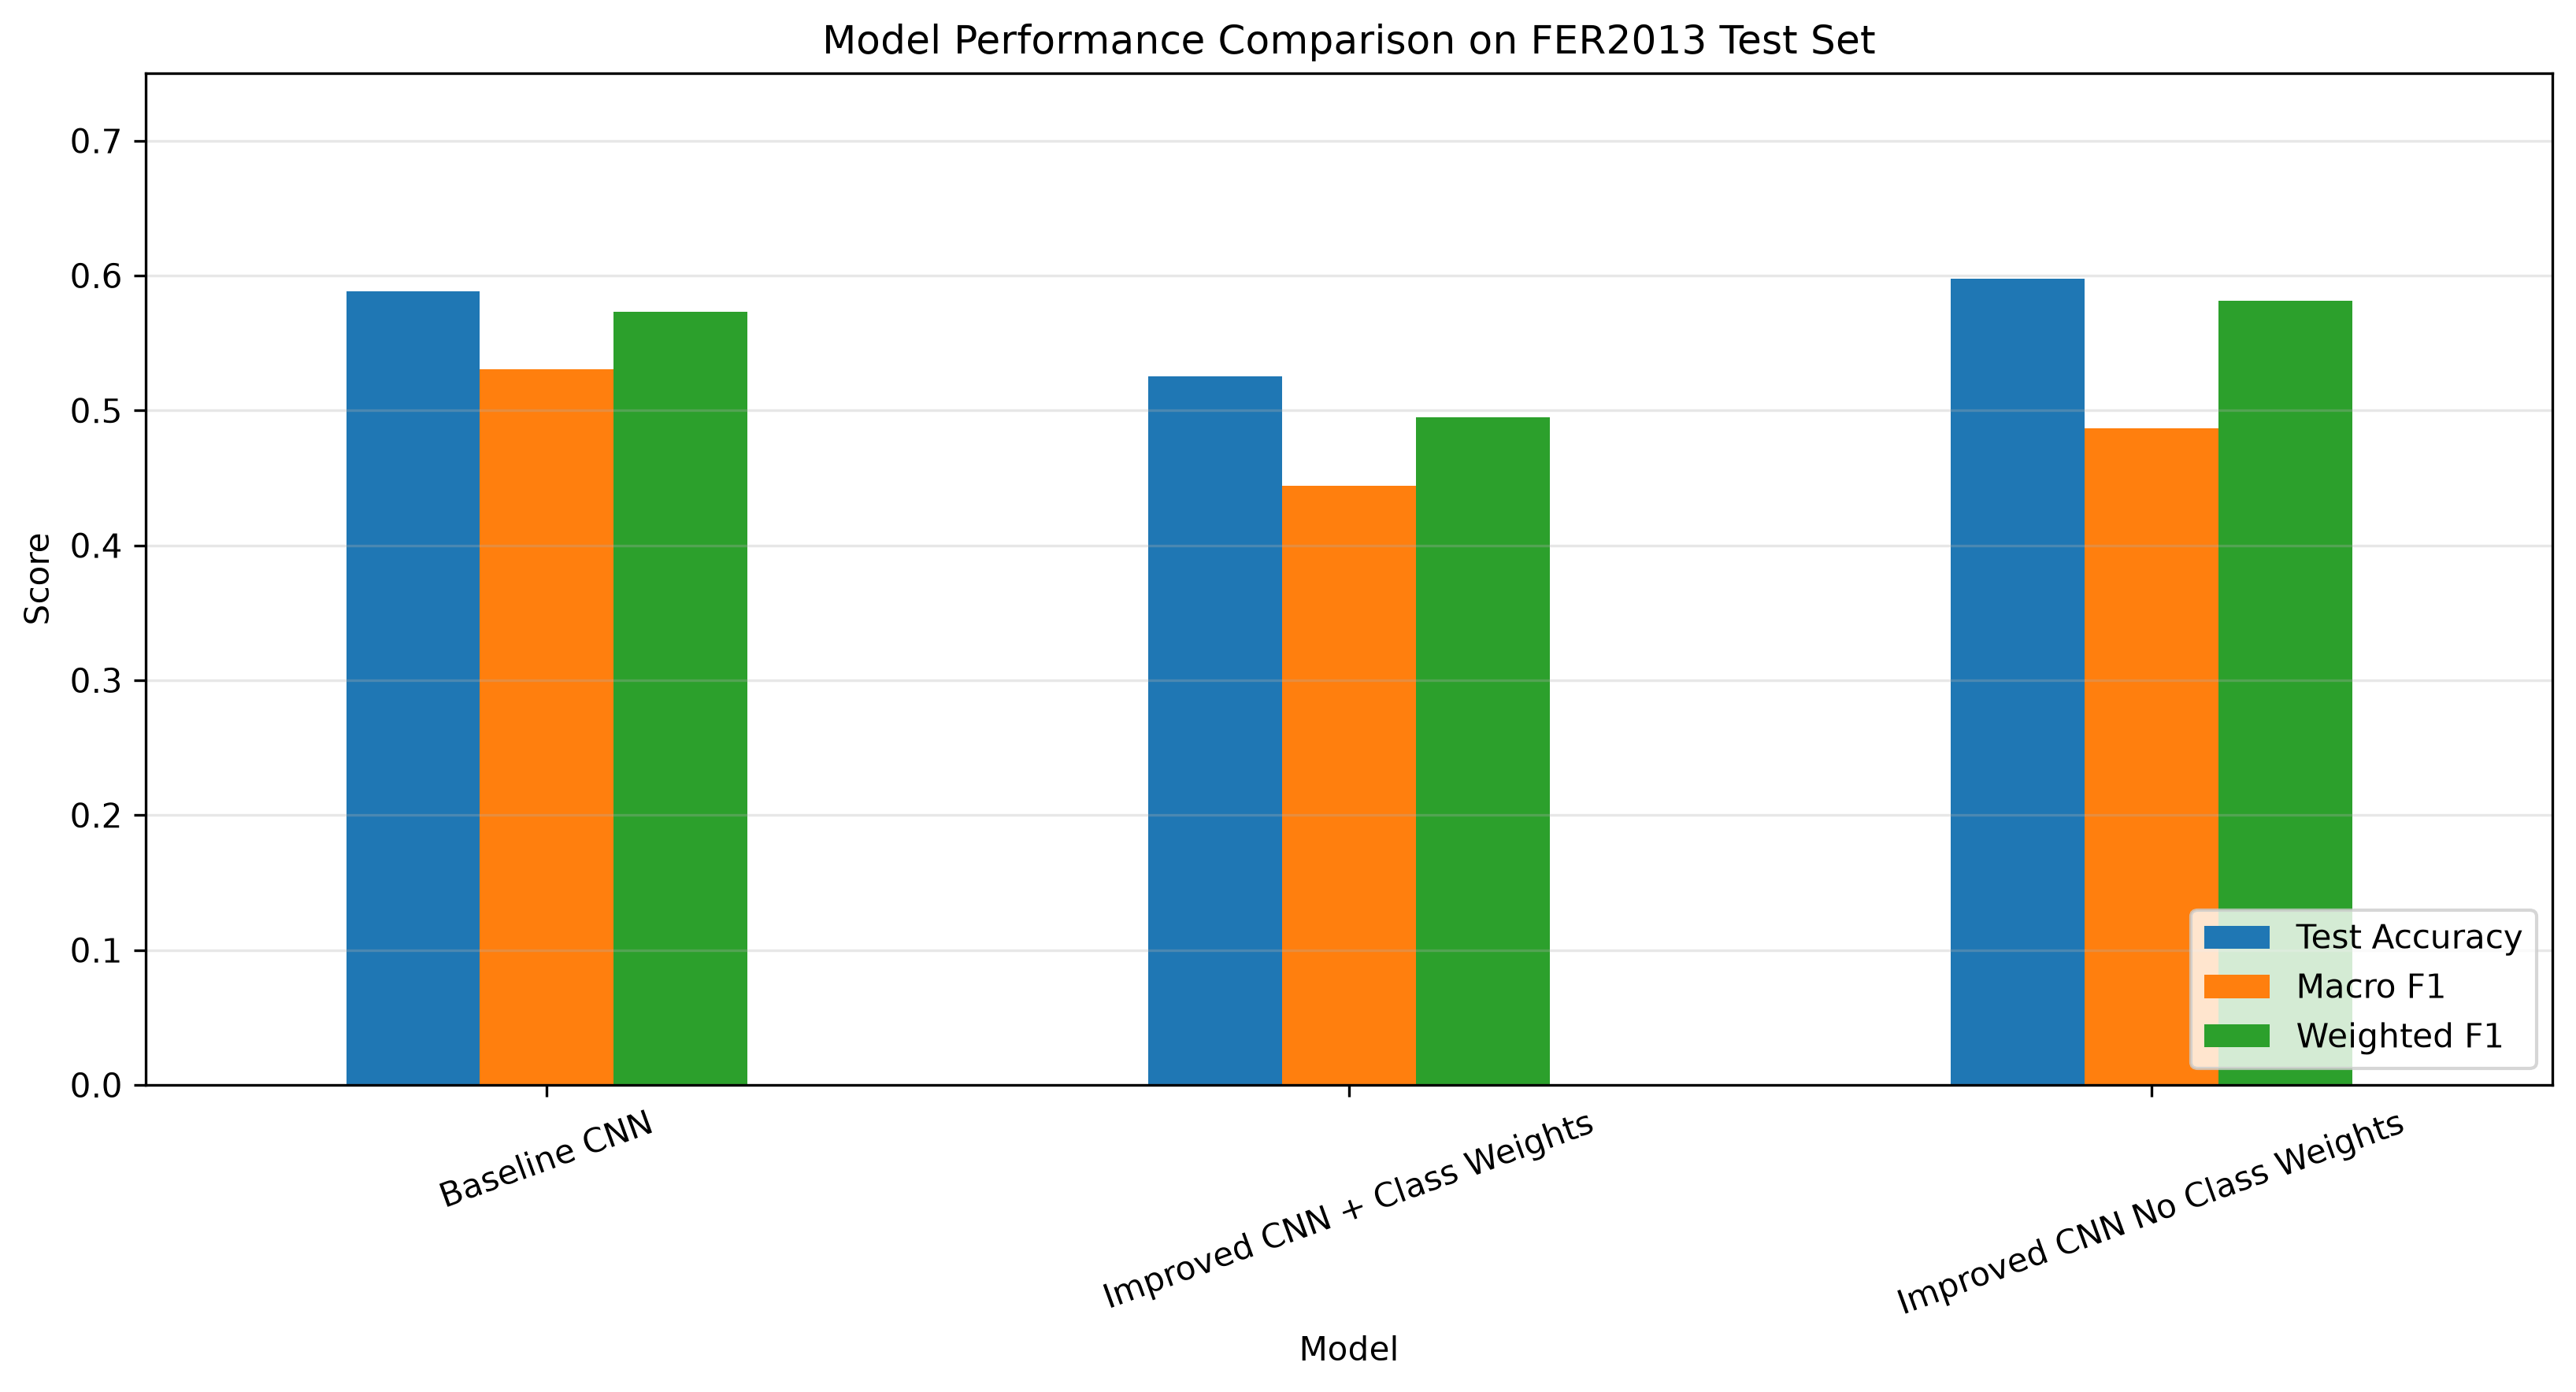

In [5]:
comparison_chart_path = FIGURES_DIR / 'model_comparison_metrics.png'
display(Image(filename=str(comparison_chart_path)))

## 7. Best Model by Metric

The best model depends on the evaluation metric. This is important because accuracy alone can hide class-level weaknesses, especially in imbalanced datasets.

In [6]:
best_rows = []

for metric in ['Test Accuracy', 'Macro F1', 'Weighted F1']:
    best_index = comparison[metric].idxmax()
    best_row = comparison.loc[best_index]
    best_rows.append({
        'Metric': metric,
        'Best Model': best_row['Model'],
        'Score': round(float(best_row[metric]), 4),
    })

best_by_metric = pd.DataFrame(best_rows)
display(best_by_metric)

,Metric,Best Model,Score
0,Test Accuracy,Improved CNN No Class Weights,0.5977
1,Macro F1,Baseline CNN,0.5304
2,Weighted F1,Improved CNN No Class Weights,0.5811


## 8. Improved CNN with Class Weights: Training History

This model uses the improved architecture, data augmentation, batch normalization, and class weights.

Class weights are intended to help minority classes such as `Disgust`, but they may also reduce overall accuracy if they over-correct the training objective.

In [7]:
improved_history = pd.read_csv(METRICS_DIR / 'improved_cnn_history.csv')

display(improved_history.head())
display(improved_history.tail())

summary_improved = pd.DataFrame({
    'Metric': [
        'Total epochs completed',
        'Best validation accuracy',
        'Best validation accuracy epoch',
        'Best validation loss',
        'Best validation loss epoch',
        'Final training accuracy',
        'Final validation accuracy',
        'Final training loss',
        'Final validation loss',
    ],
    'Value': [
        len(improved_history),
        round(float(improved_history['val_accuracy'].max()), 4),
        int(improved_history['val_accuracy'].idxmax() + 1),
        round(float(improved_history['val_loss'].min()), 4),
        int(improved_history['val_loss'].idxmin() + 1),
        round(float(improved_history.iloc[-1]['accuracy']), 4),
        round(float(improved_history.iloc[-1]['val_accuracy']), 4),
        round(float(improved_history.iloc[-1]['loss']), 4),
        round(float(improved_history.iloc[-1]['val_loss']), 4),
    ],
})

display(summary_improved)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.172664,1.938118,0.252717,1.950569,0.001
1,0.193284,1.900929,0.181945,1.955165,0.001
2,0.212547,1.829048,0.176372,1.937480,0.001
3,0.239437,1.793757,0.265812,1.780501,0.001
4,0.269950,1.764705,0.332405,1.609165,0.001


,accuracy,loss,val_accuracy,val_loss,learning_rate
20,0.453586,1.406984,0.489551,1.276774,0.0005
21,0.458358,1.393101,0.496238,1.243183,0.0005
22,0.459682,1.388462,0.499303,1.273395,0.0005
23,0.460274,1.388968,0.515185,1.246018,0.0005
24,0.465568,1.371128,0.496796,1.277450,0.0005


,Metric,Value
0,Total epochs completed,25.0000
1,Best validation accuracy,0.5152
2,Best validation accuracy epoch,24.0000
3,Best validation loss,1.2432
4,Best validation loss epoch,22.0000
5,Final training accuracy,0.4656
6,Final validation accuracy,0.4968
7,Final training loss,1.3711
8,Final validation loss,1.2774


### Improved CNN with Class Weights: Accuracy Curve

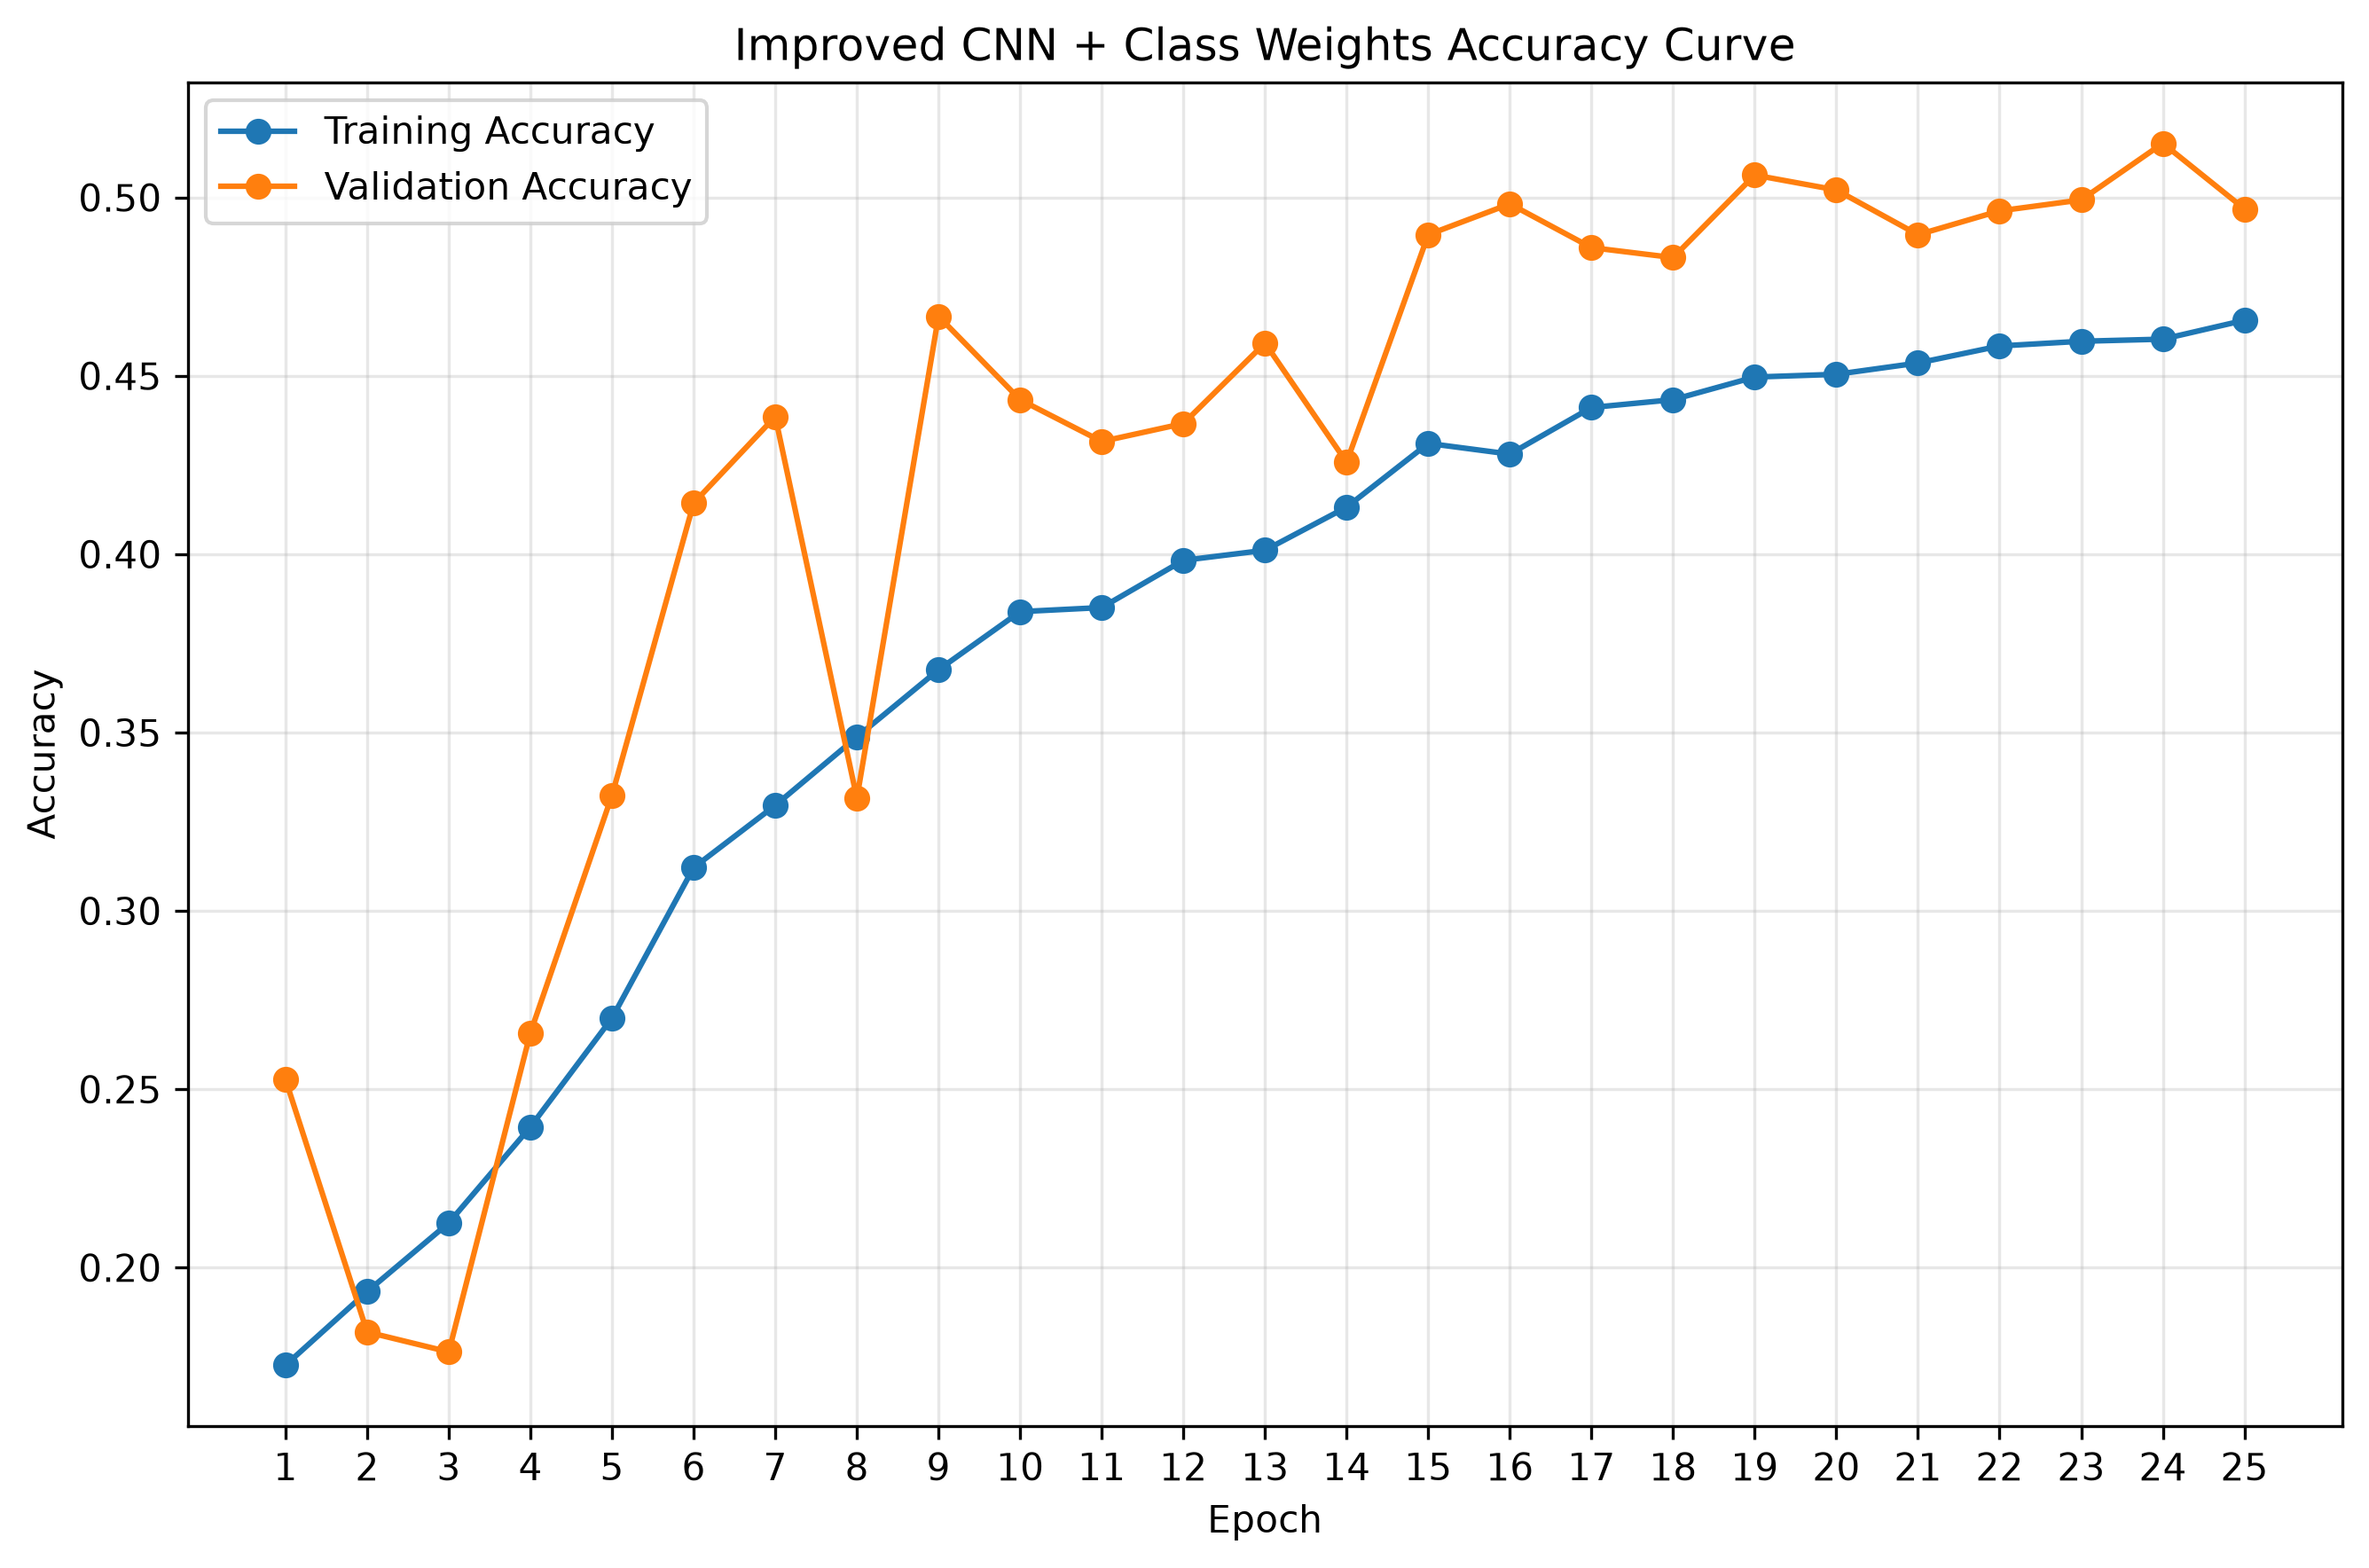

In [8]:
display(Image(filename=str(FIGURES_DIR / 'improved_cnn_accuracy_curve.png')))

### Improved CNN with Class Weights: Loss Curve

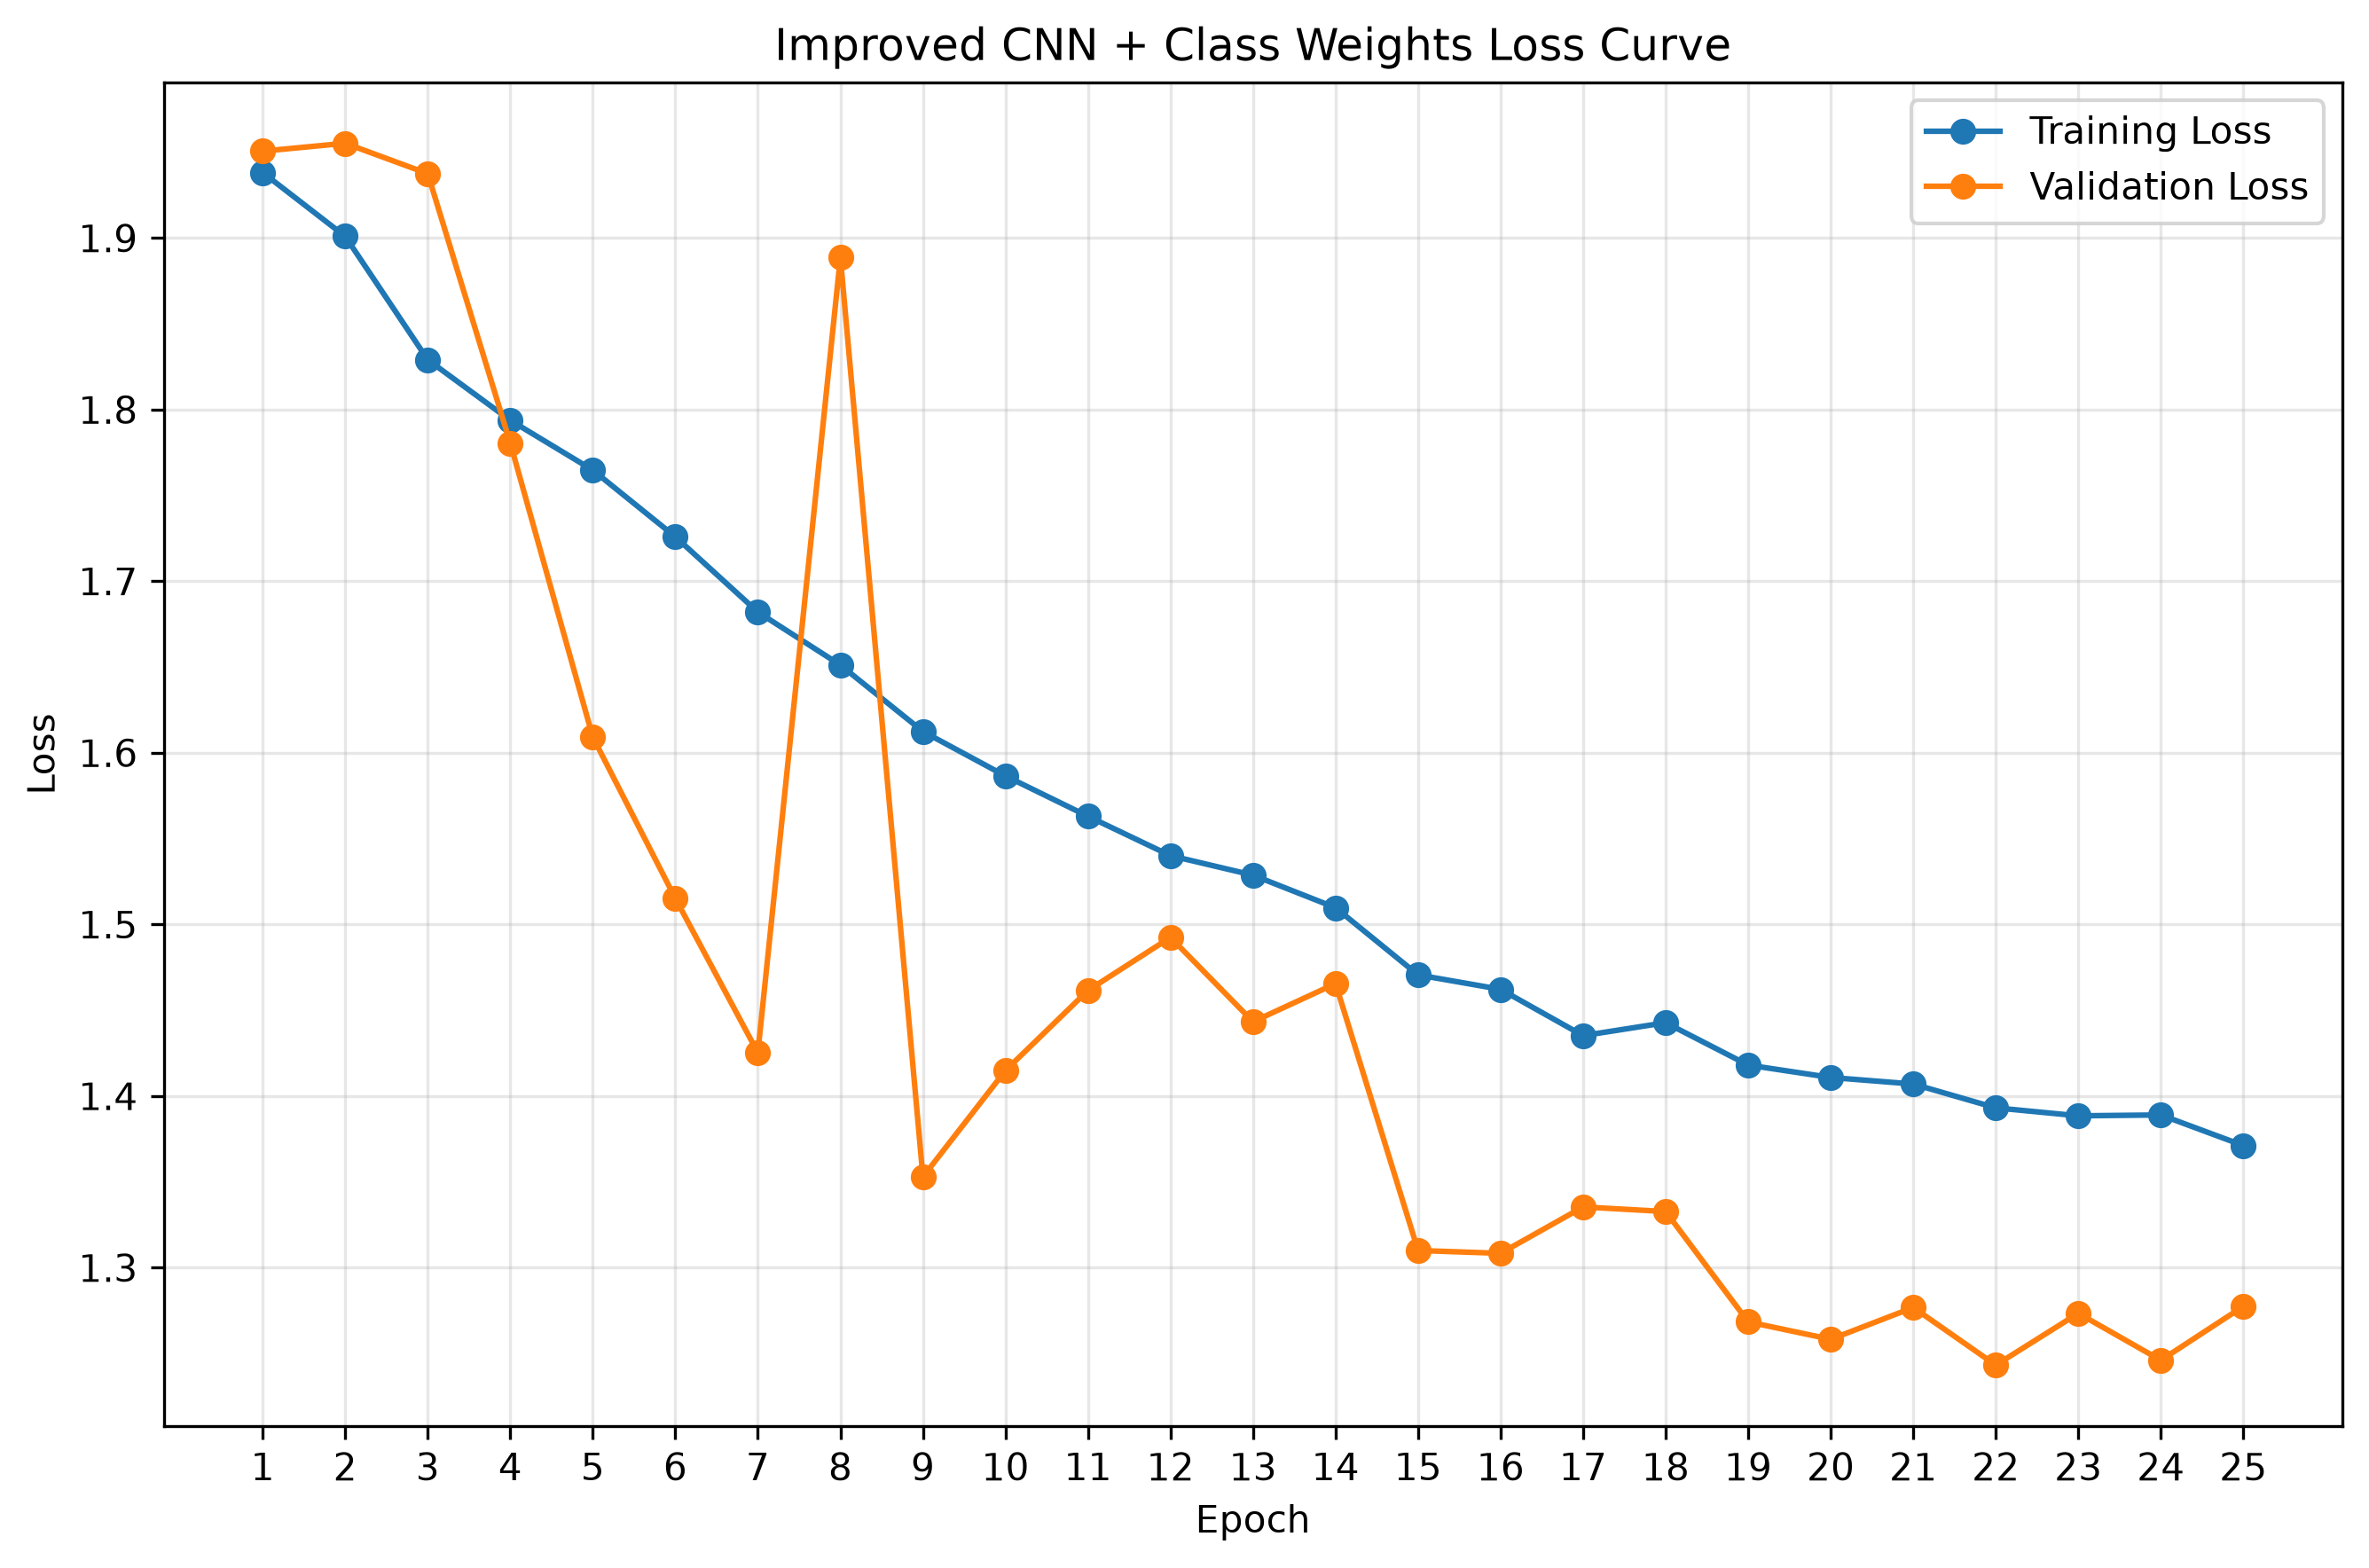

In [9]:
display(Image(filename=str(FIGURES_DIR / 'improved_cnn_loss_curve.png')))

## 9. Improved CNN with Class Weights: Test Results

The classification report shows how the class-weighted model performs on each emotion class.

In [10]:
with (METRICS_DIR / 'improved_cnn_classification_report.txt').open('r', encoding='utf-8') as file:
    improved_report = file.read()

print(improved_report)

              precision    recall  f1-score   support

       Angry       0.37      0.31      0.34       491
     Disgust       0.24      0.40      0.30        55
        Fear       0.30      0.06      0.10       528
       Happy       0.84      0.79      0.81       879
         Sad       0.37      0.34      0.35       594
    Surprise       0.54      0.83      0.65       416
     Neutral       0.45      0.69      0.55       626

    accuracy                           0.53      3589
   macro avg       0.44      0.49      0.44      3589
weighted avg       0.51      0.53      0.49      3589



### Improved CNN with Class Weights: Confusion Matrix

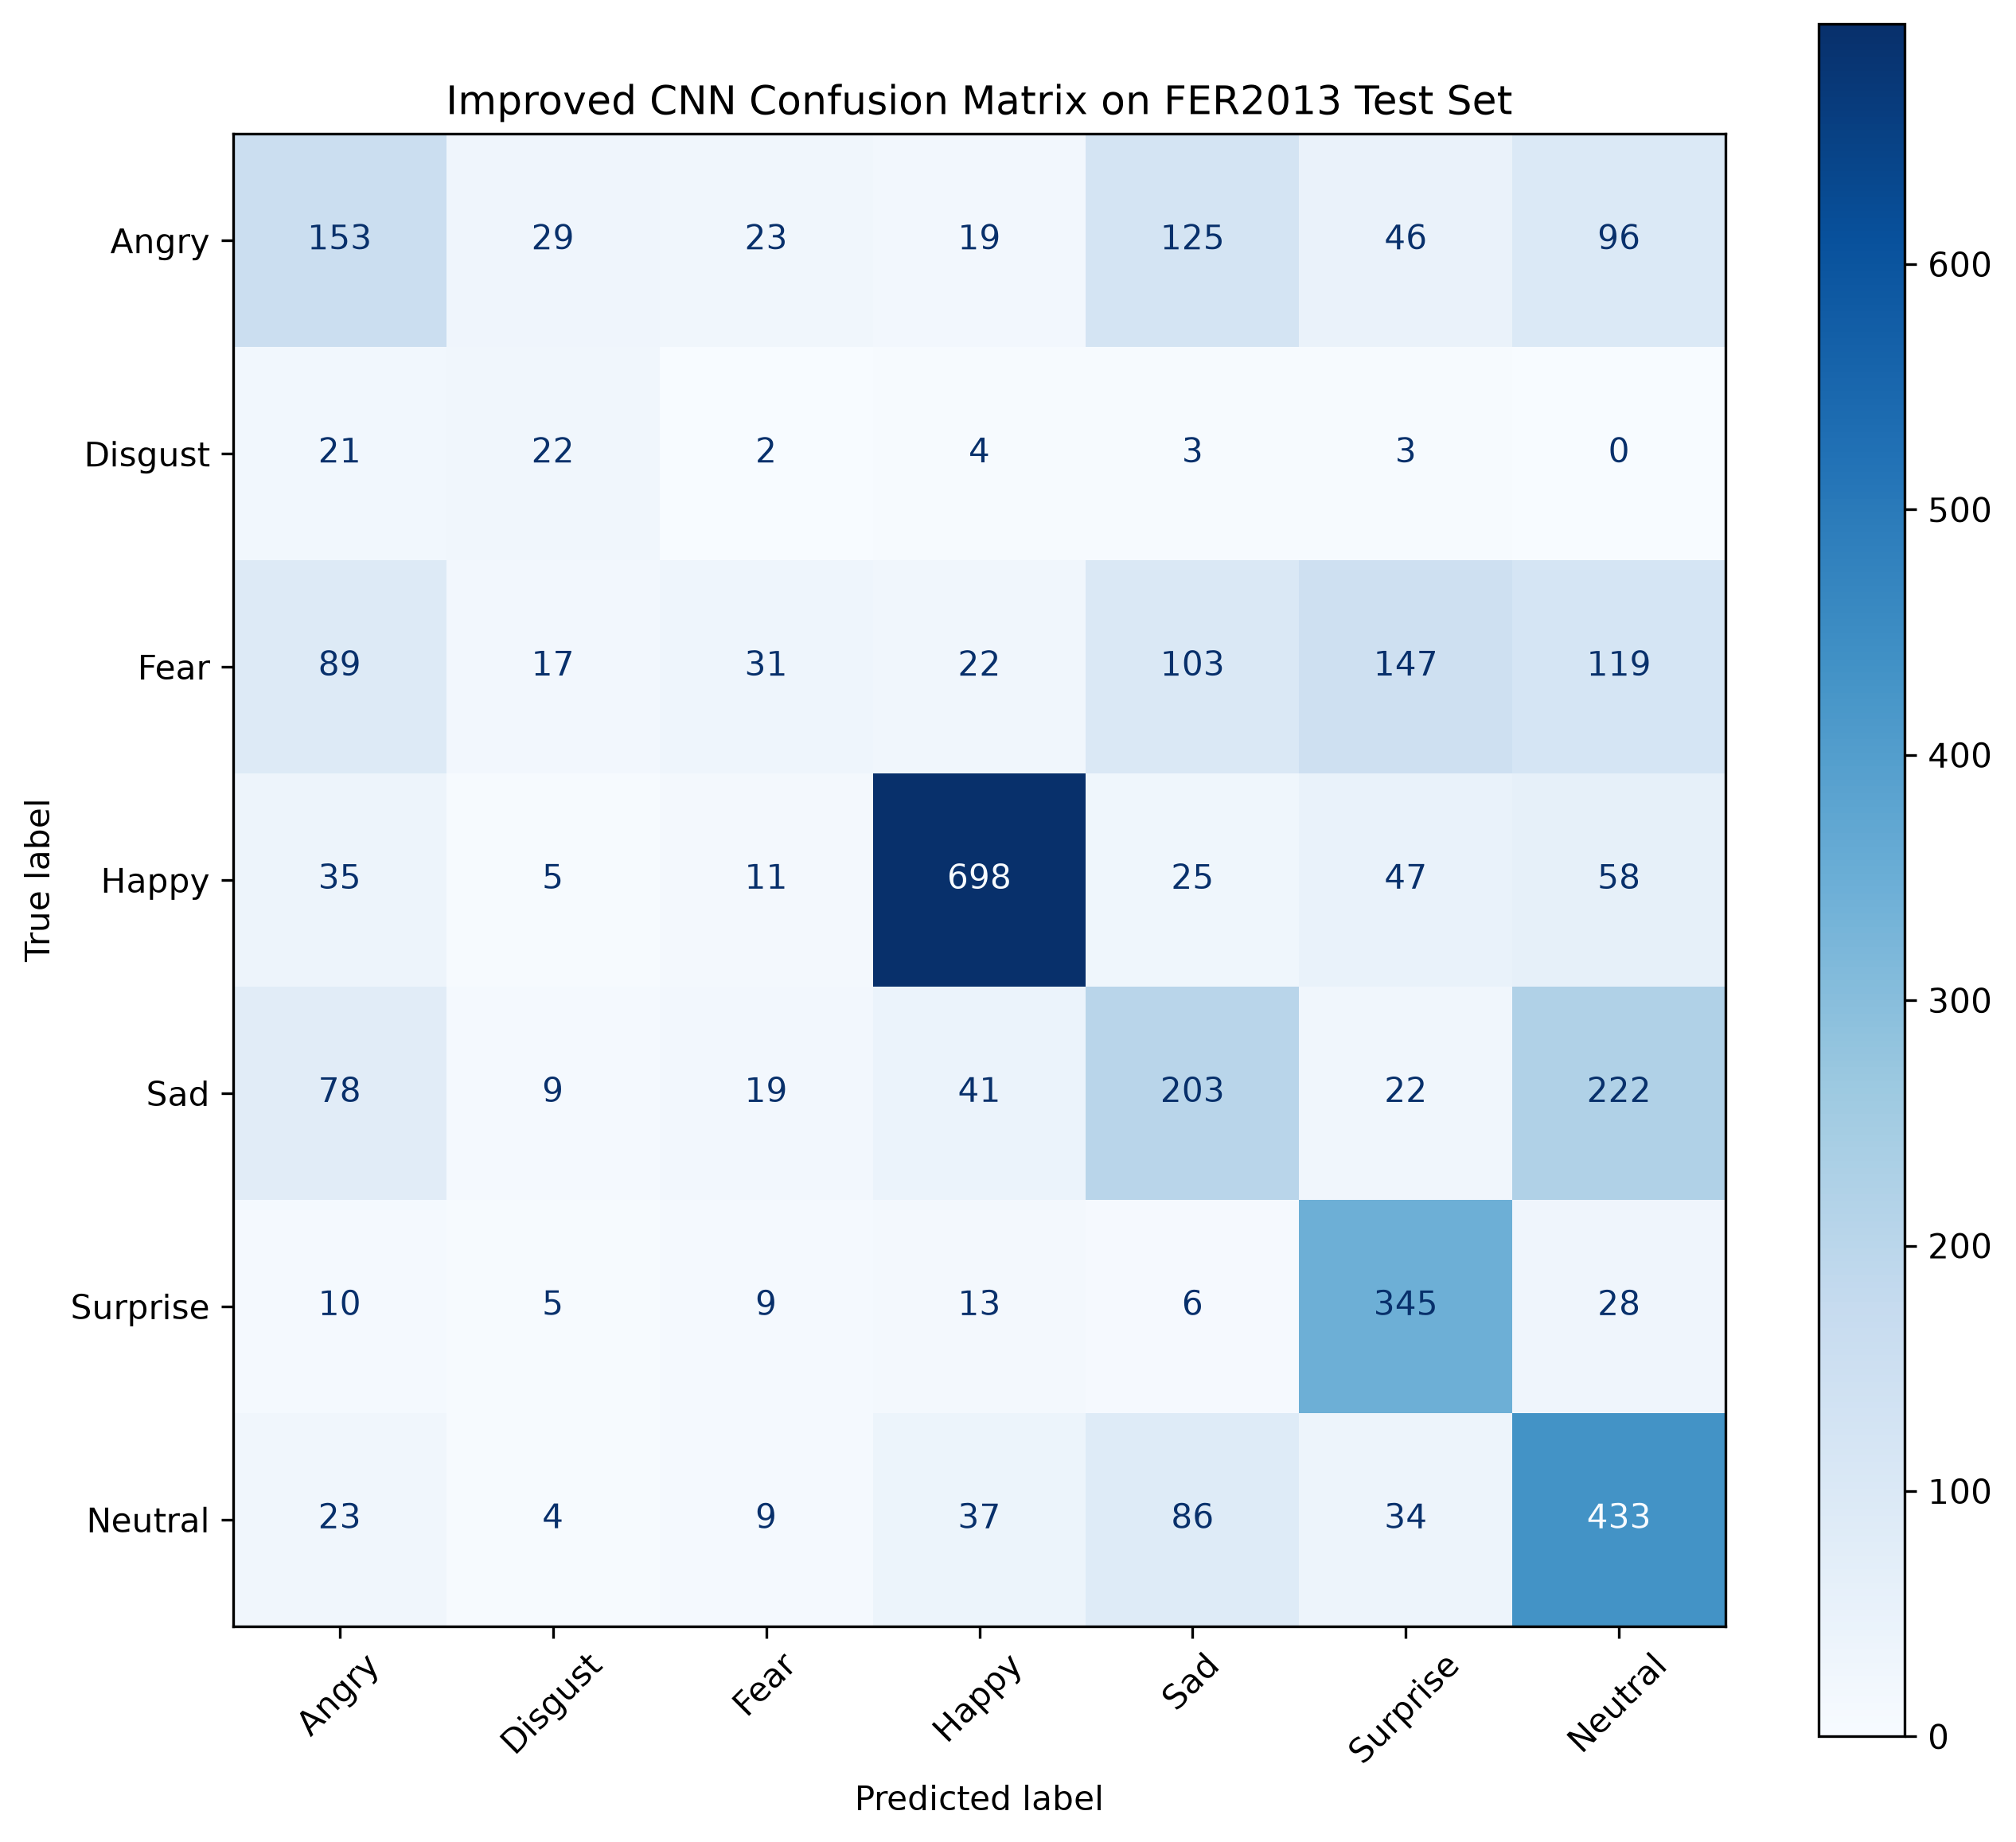

In [11]:
display(Image(filename=str(FIGURES_DIR / 'improved_cnn_confusion_matrix.png')))

## 10. Improved CNN without Class Weights: Training History

This model uses the improved architecture and data augmentation, but disables class weights.

This experiment tests whether the architecture and augmentation alone can improve performance without over-correcting for class imbalance.

In [12]:
no_cw_history = pd.read_csv(METRICS_DIR / 'improved_cnn_no_class_weights_history.csv')

display(no_cw_history.head())
display(no_cw_history.tail())

summary_no_cw = pd.DataFrame({
    'Metric': [
        'Total epochs completed',
        'Best validation accuracy',
        'Best validation accuracy epoch',
        'Best validation loss',
        'Best validation loss epoch',
        'Final training accuracy',
        'Final validation accuracy',
        'Final training loss',
        'Final validation loss',
    ],
    'Value': [
        len(no_cw_history),
        round(float(no_cw_history['val_accuracy'].max()), 4),
        int(no_cw_history['val_accuracy'].idxmax() + 1),
        round(float(no_cw_history['val_loss'].min()), 4),
        int(no_cw_history['val_loss'].idxmin() + 1),
        round(float(no_cw_history.iloc[-1]['accuracy']), 4),
        round(float(no_cw_history.iloc[-1]['val_accuracy']), 4),
        round(float(no_cw_history.iloc[-1]['loss']), 4),
        round(float(no_cw_history.iloc[-1]['val_loss']), 4),
    ],
})

display(summary_no_cw)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.257341,1.791922,0.249930,2.451169,0.001
1,0.337908,1.656519,0.359989,1.828792,0.001
2,0.402870,1.532807,0.370298,1.616668,0.001
3,0.432164,1.472300,0.407077,1.488998,0.001
4,0.452576,1.423666,0.456673,1.393511,0.001


,accuracy,loss,val_accuracy,val_loss,learning_rate
20,0.570344,1.155889,0.560880,1.171383,0.0005
21,0.576405,1.141273,0.585678,1.111168,0.0005
22,0.579679,1.133344,0.577877,1.120384,0.0005
23,0.579052,1.134218,0.568961,1.150592,0.0005
24,0.580584,1.130710,0.584007,1.099529,0.0005


,Metric,Value
0,Total epochs completed,25.0000
1,Best validation accuracy,0.5940
2,Best validation accuracy epoch,20.0000
3,Best validation loss,1.0995
4,Best validation loss epoch,25.0000
5,Final training accuracy,0.5806
6,Final validation accuracy,0.5840
7,Final training loss,1.1307
8,Final validation loss,1.0995


### Improved CNN without Class Weights: Accuracy Curve

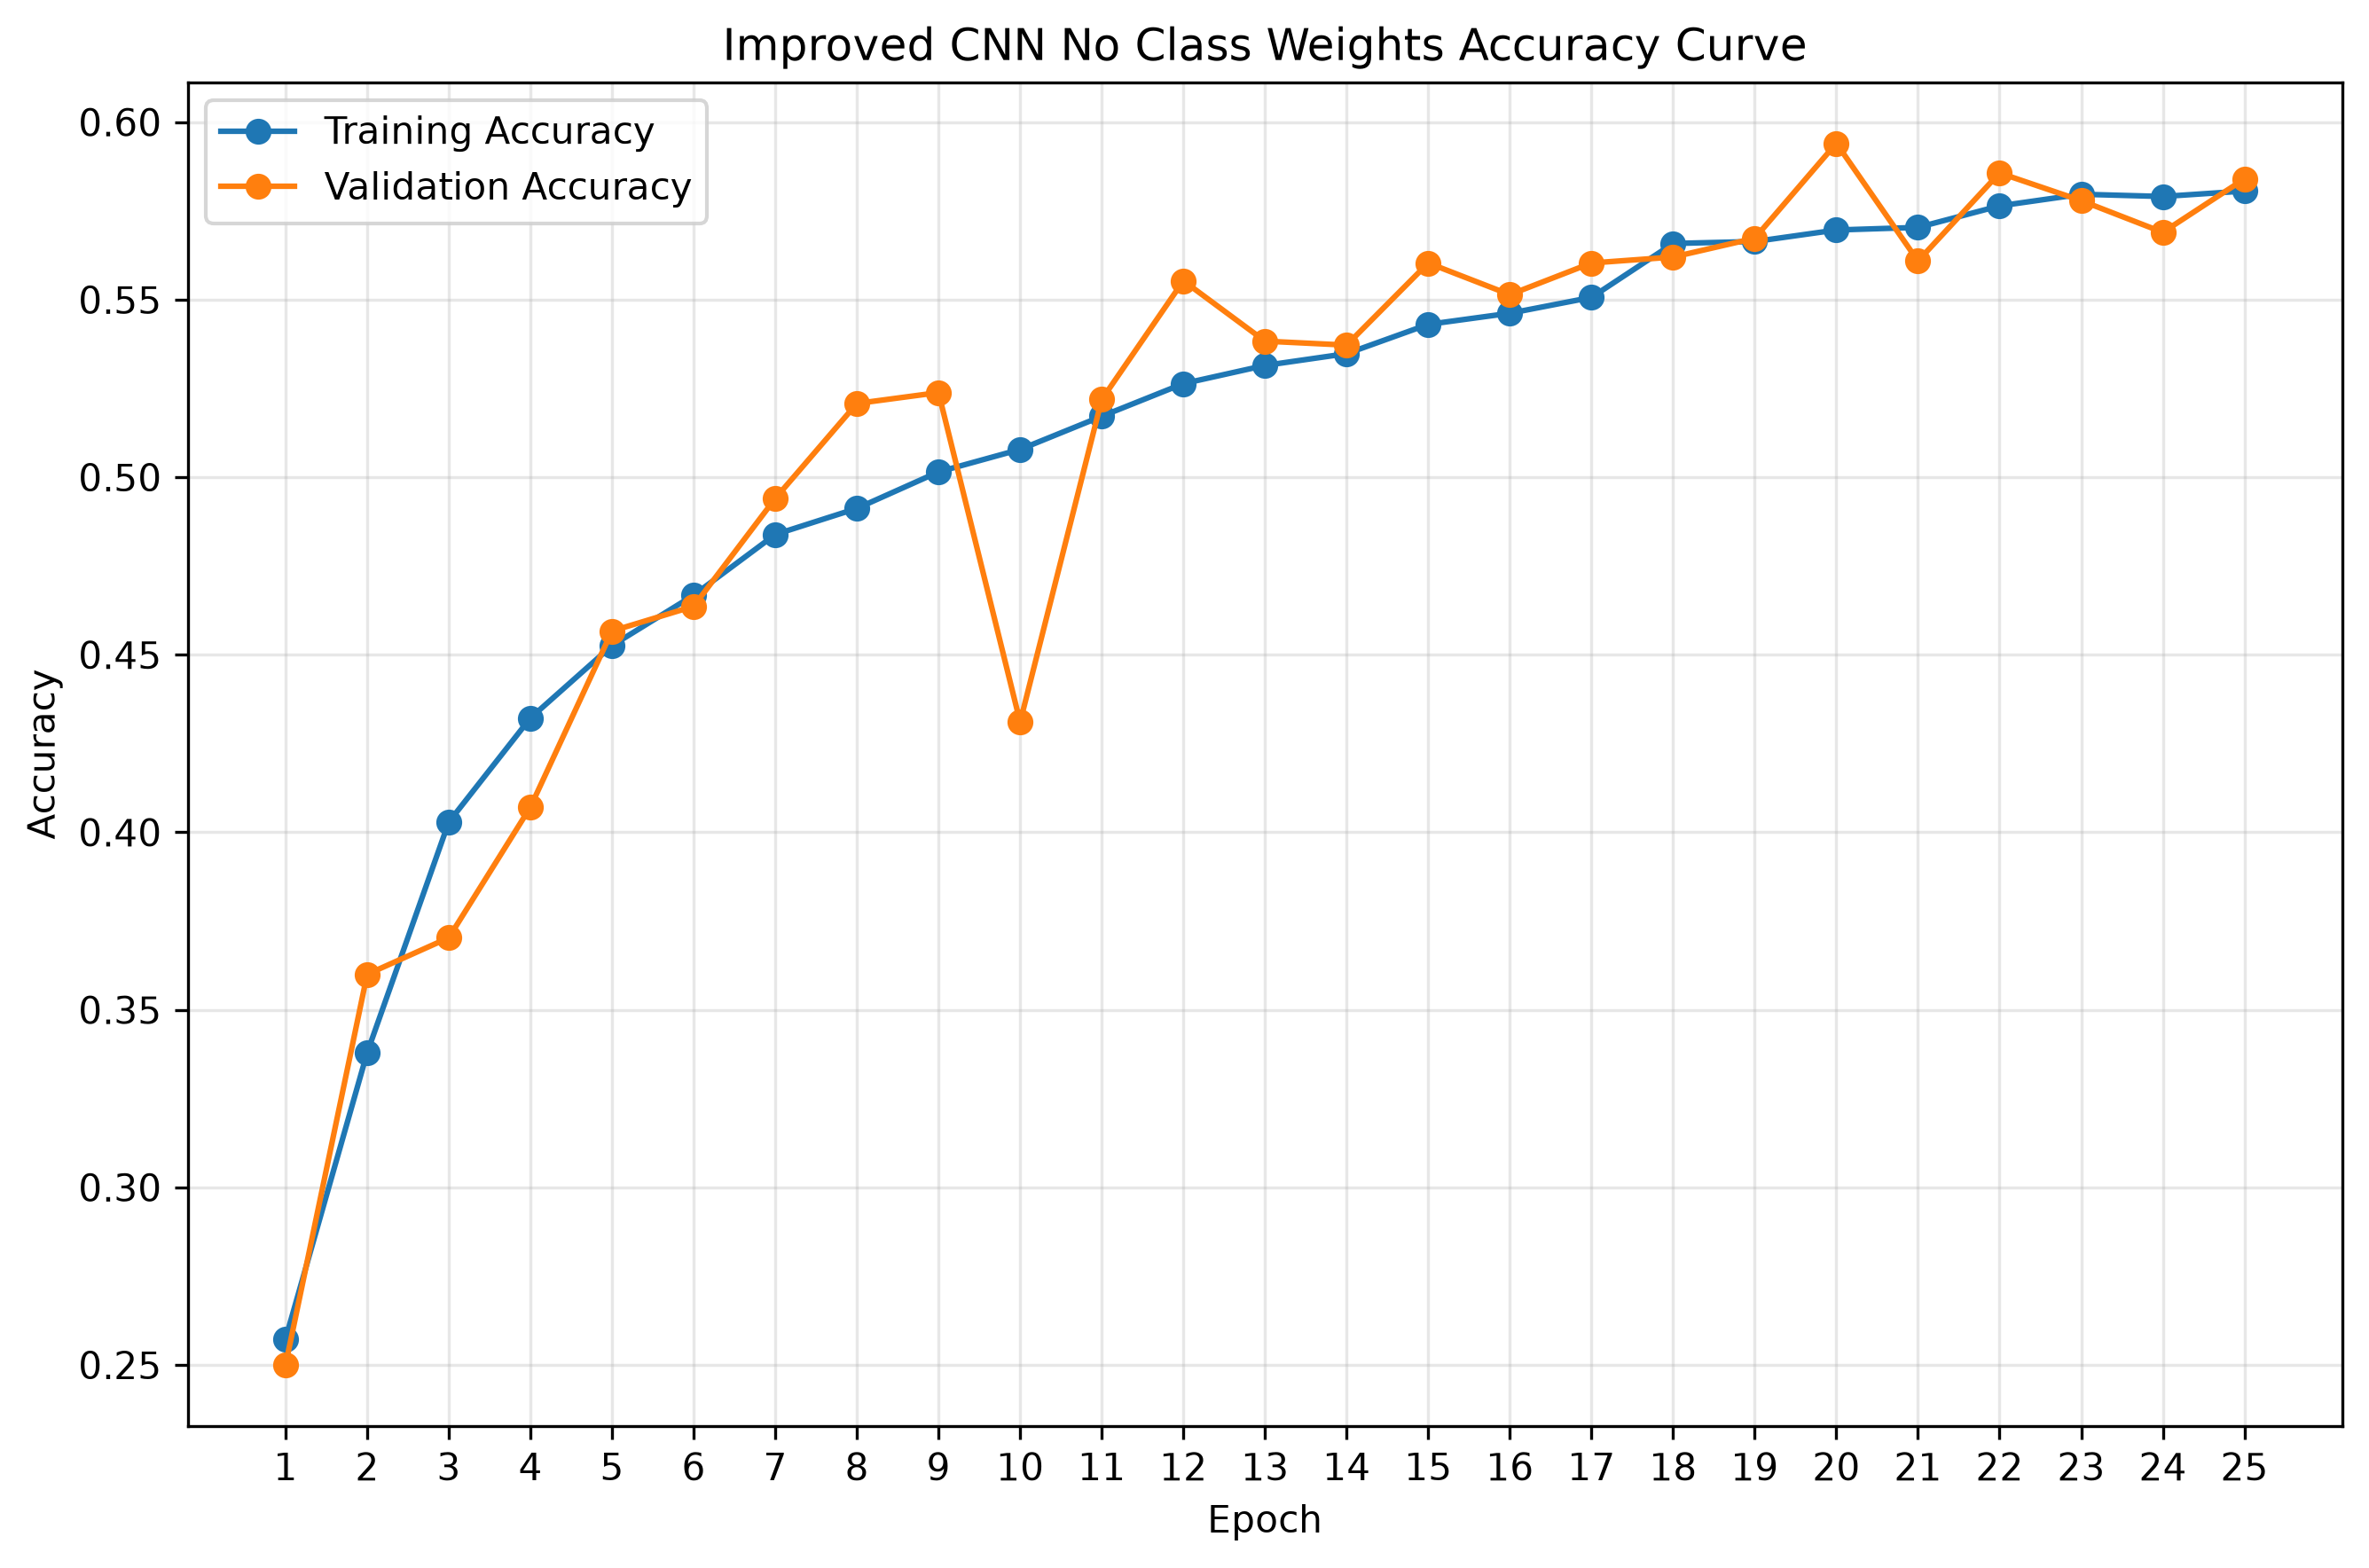

In [13]:
display(Image(filename=str(FIGURES_DIR / 'improved_cnn_no_class_weights_accuracy_curve.png')))

### Improved CNN without Class Weights: Loss Curve

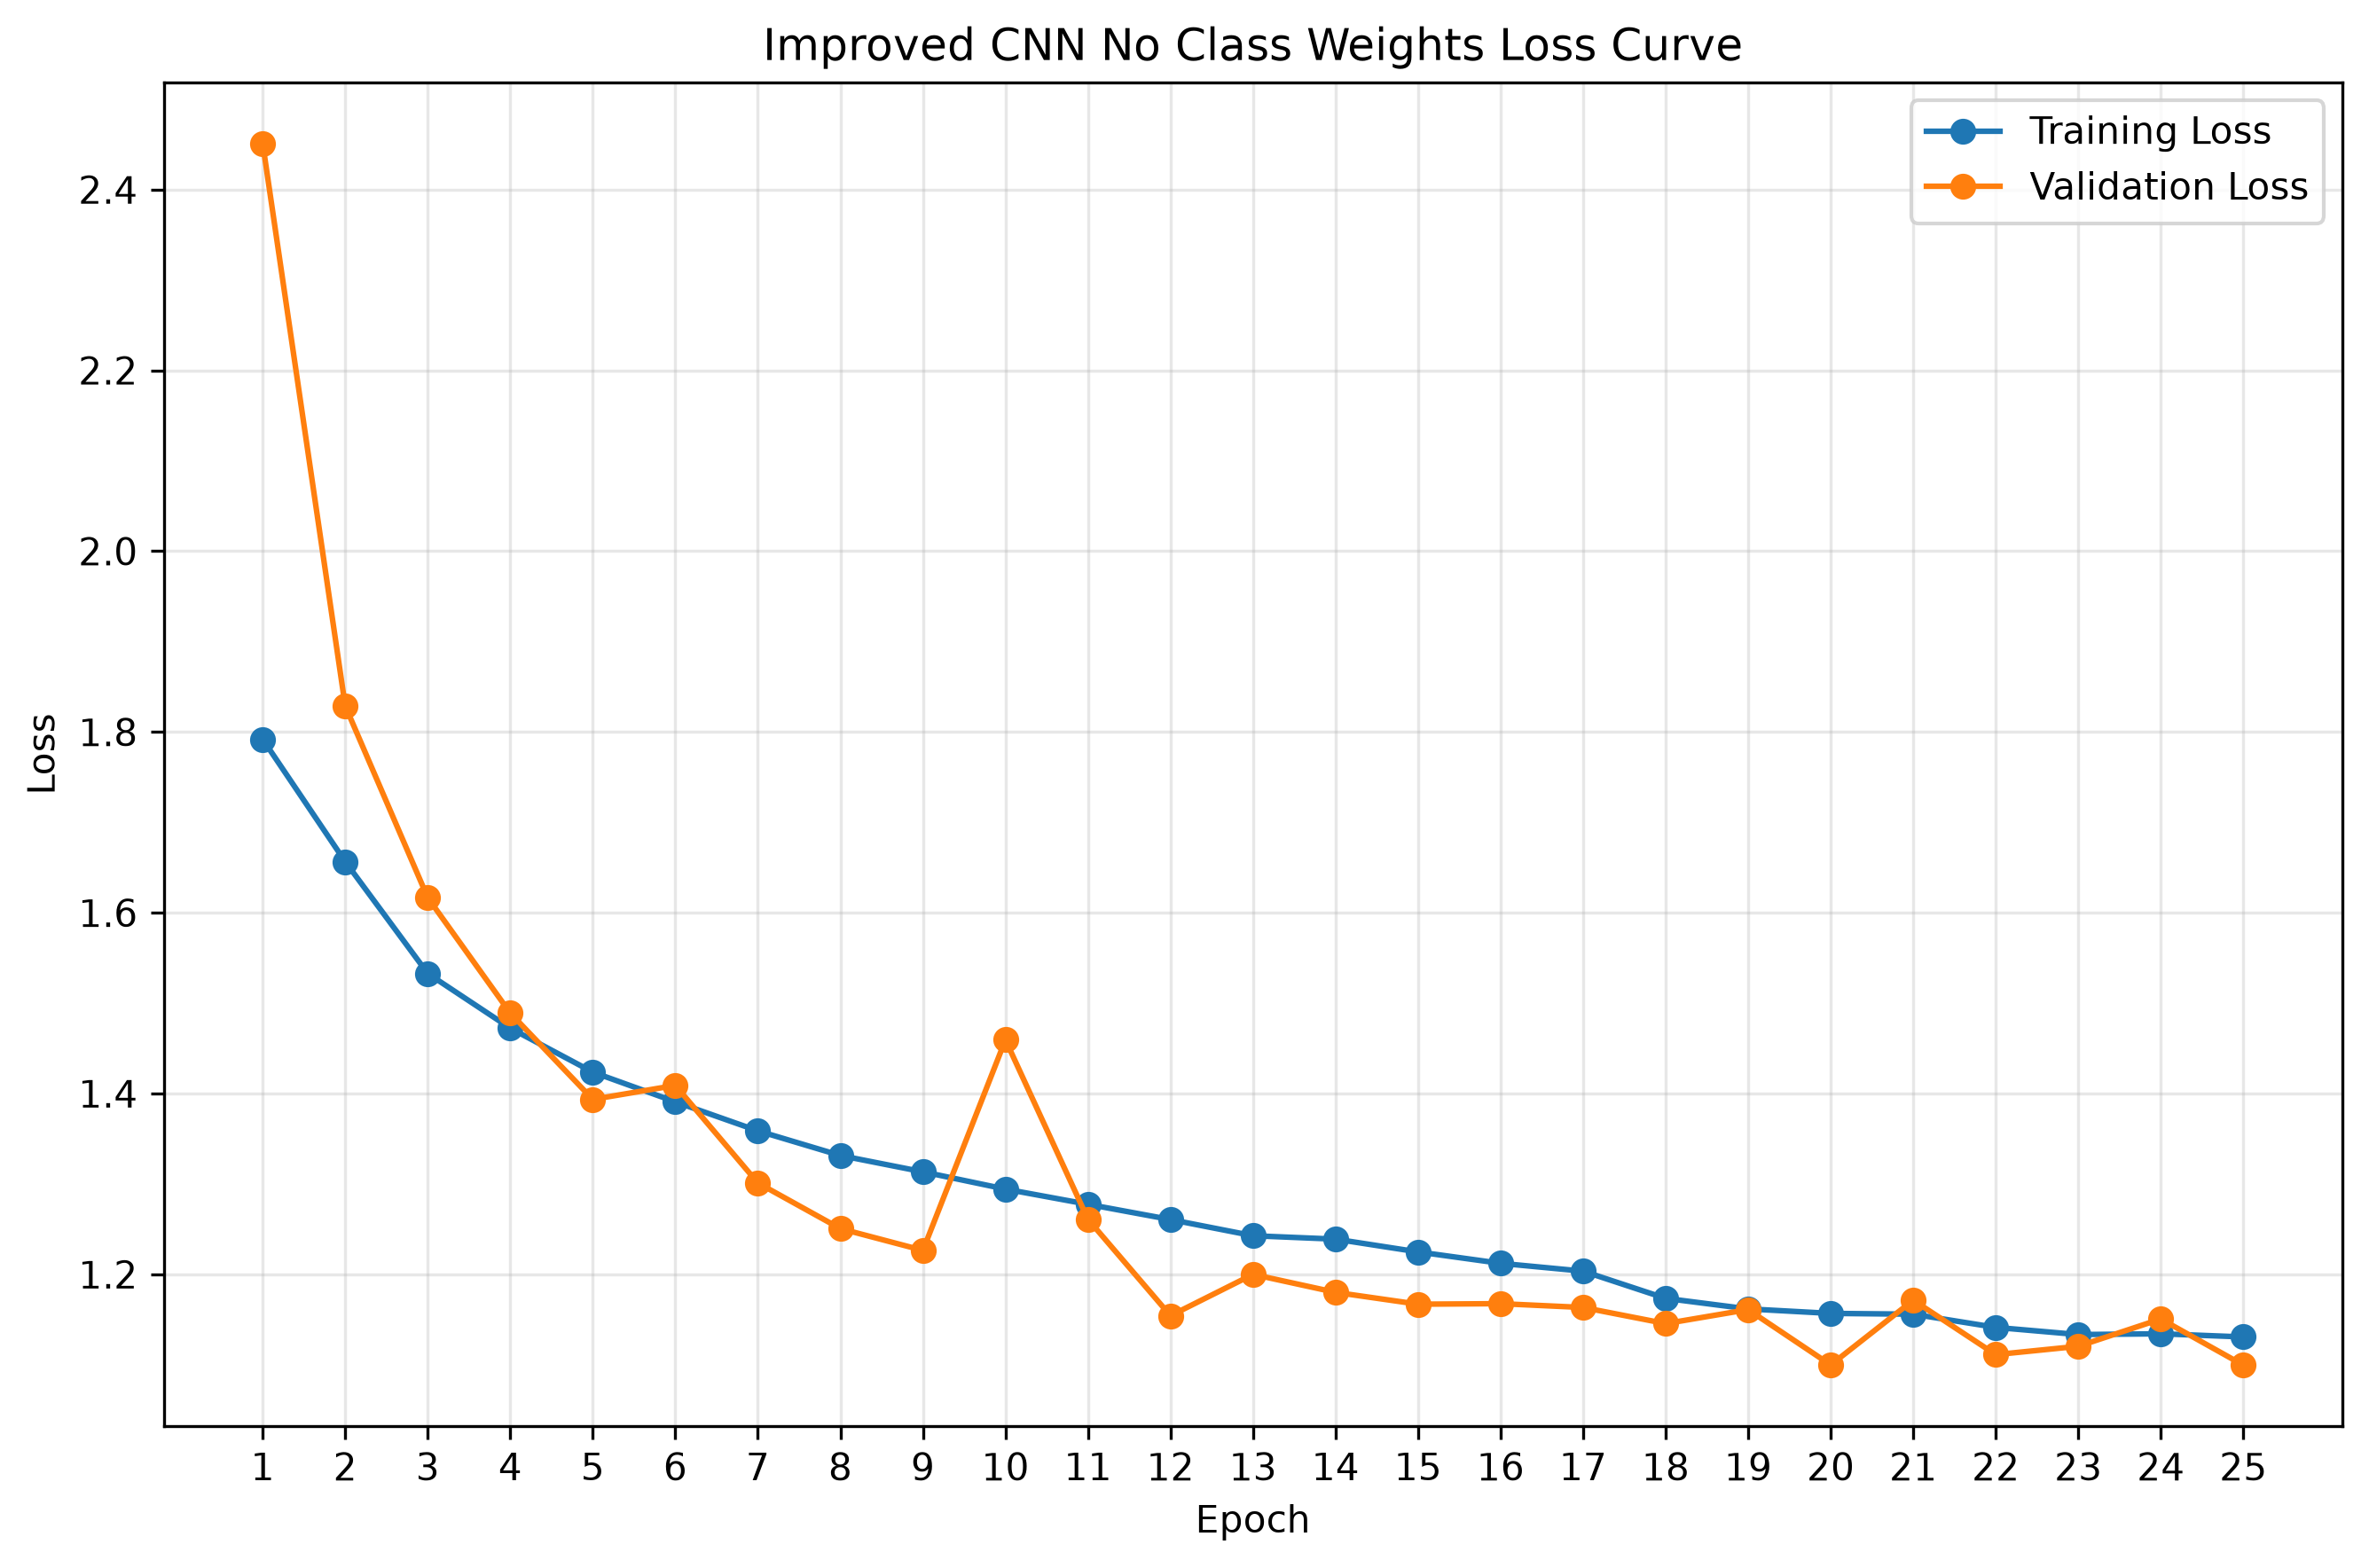

In [14]:
display(Image(filename=str(FIGURES_DIR / 'improved_cnn_no_class_weights_loss_curve.png')))

## 11. Improved CNN without Class Weights: Test Results

The classification report below shows the final per-class performance of the best overall model by test accuracy and weighted F1-score.

In [15]:
with (METRICS_DIR / 'improved_cnn_no_class_weights_classification_report.txt').open('r', encoding='utf-8') as file:
    no_cw_report = file.read()

print(no_cw_report)

              precision    recall  f1-score   support

       Angry       0.46      0.52      0.49       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.42      0.21      0.28       528
       Happy       0.84      0.84      0.84       879
         Sad       0.46      0.49      0.47       594
    Surprise       0.67      0.79      0.73       416
     Neutral       0.55      0.67      0.60       626

    accuracy                           0.60      3589
   macro avg       0.49      0.50      0.49      3589
weighted avg       0.58      0.60      0.58      3589



### Improved CNN without Class Weights: Confusion Matrix

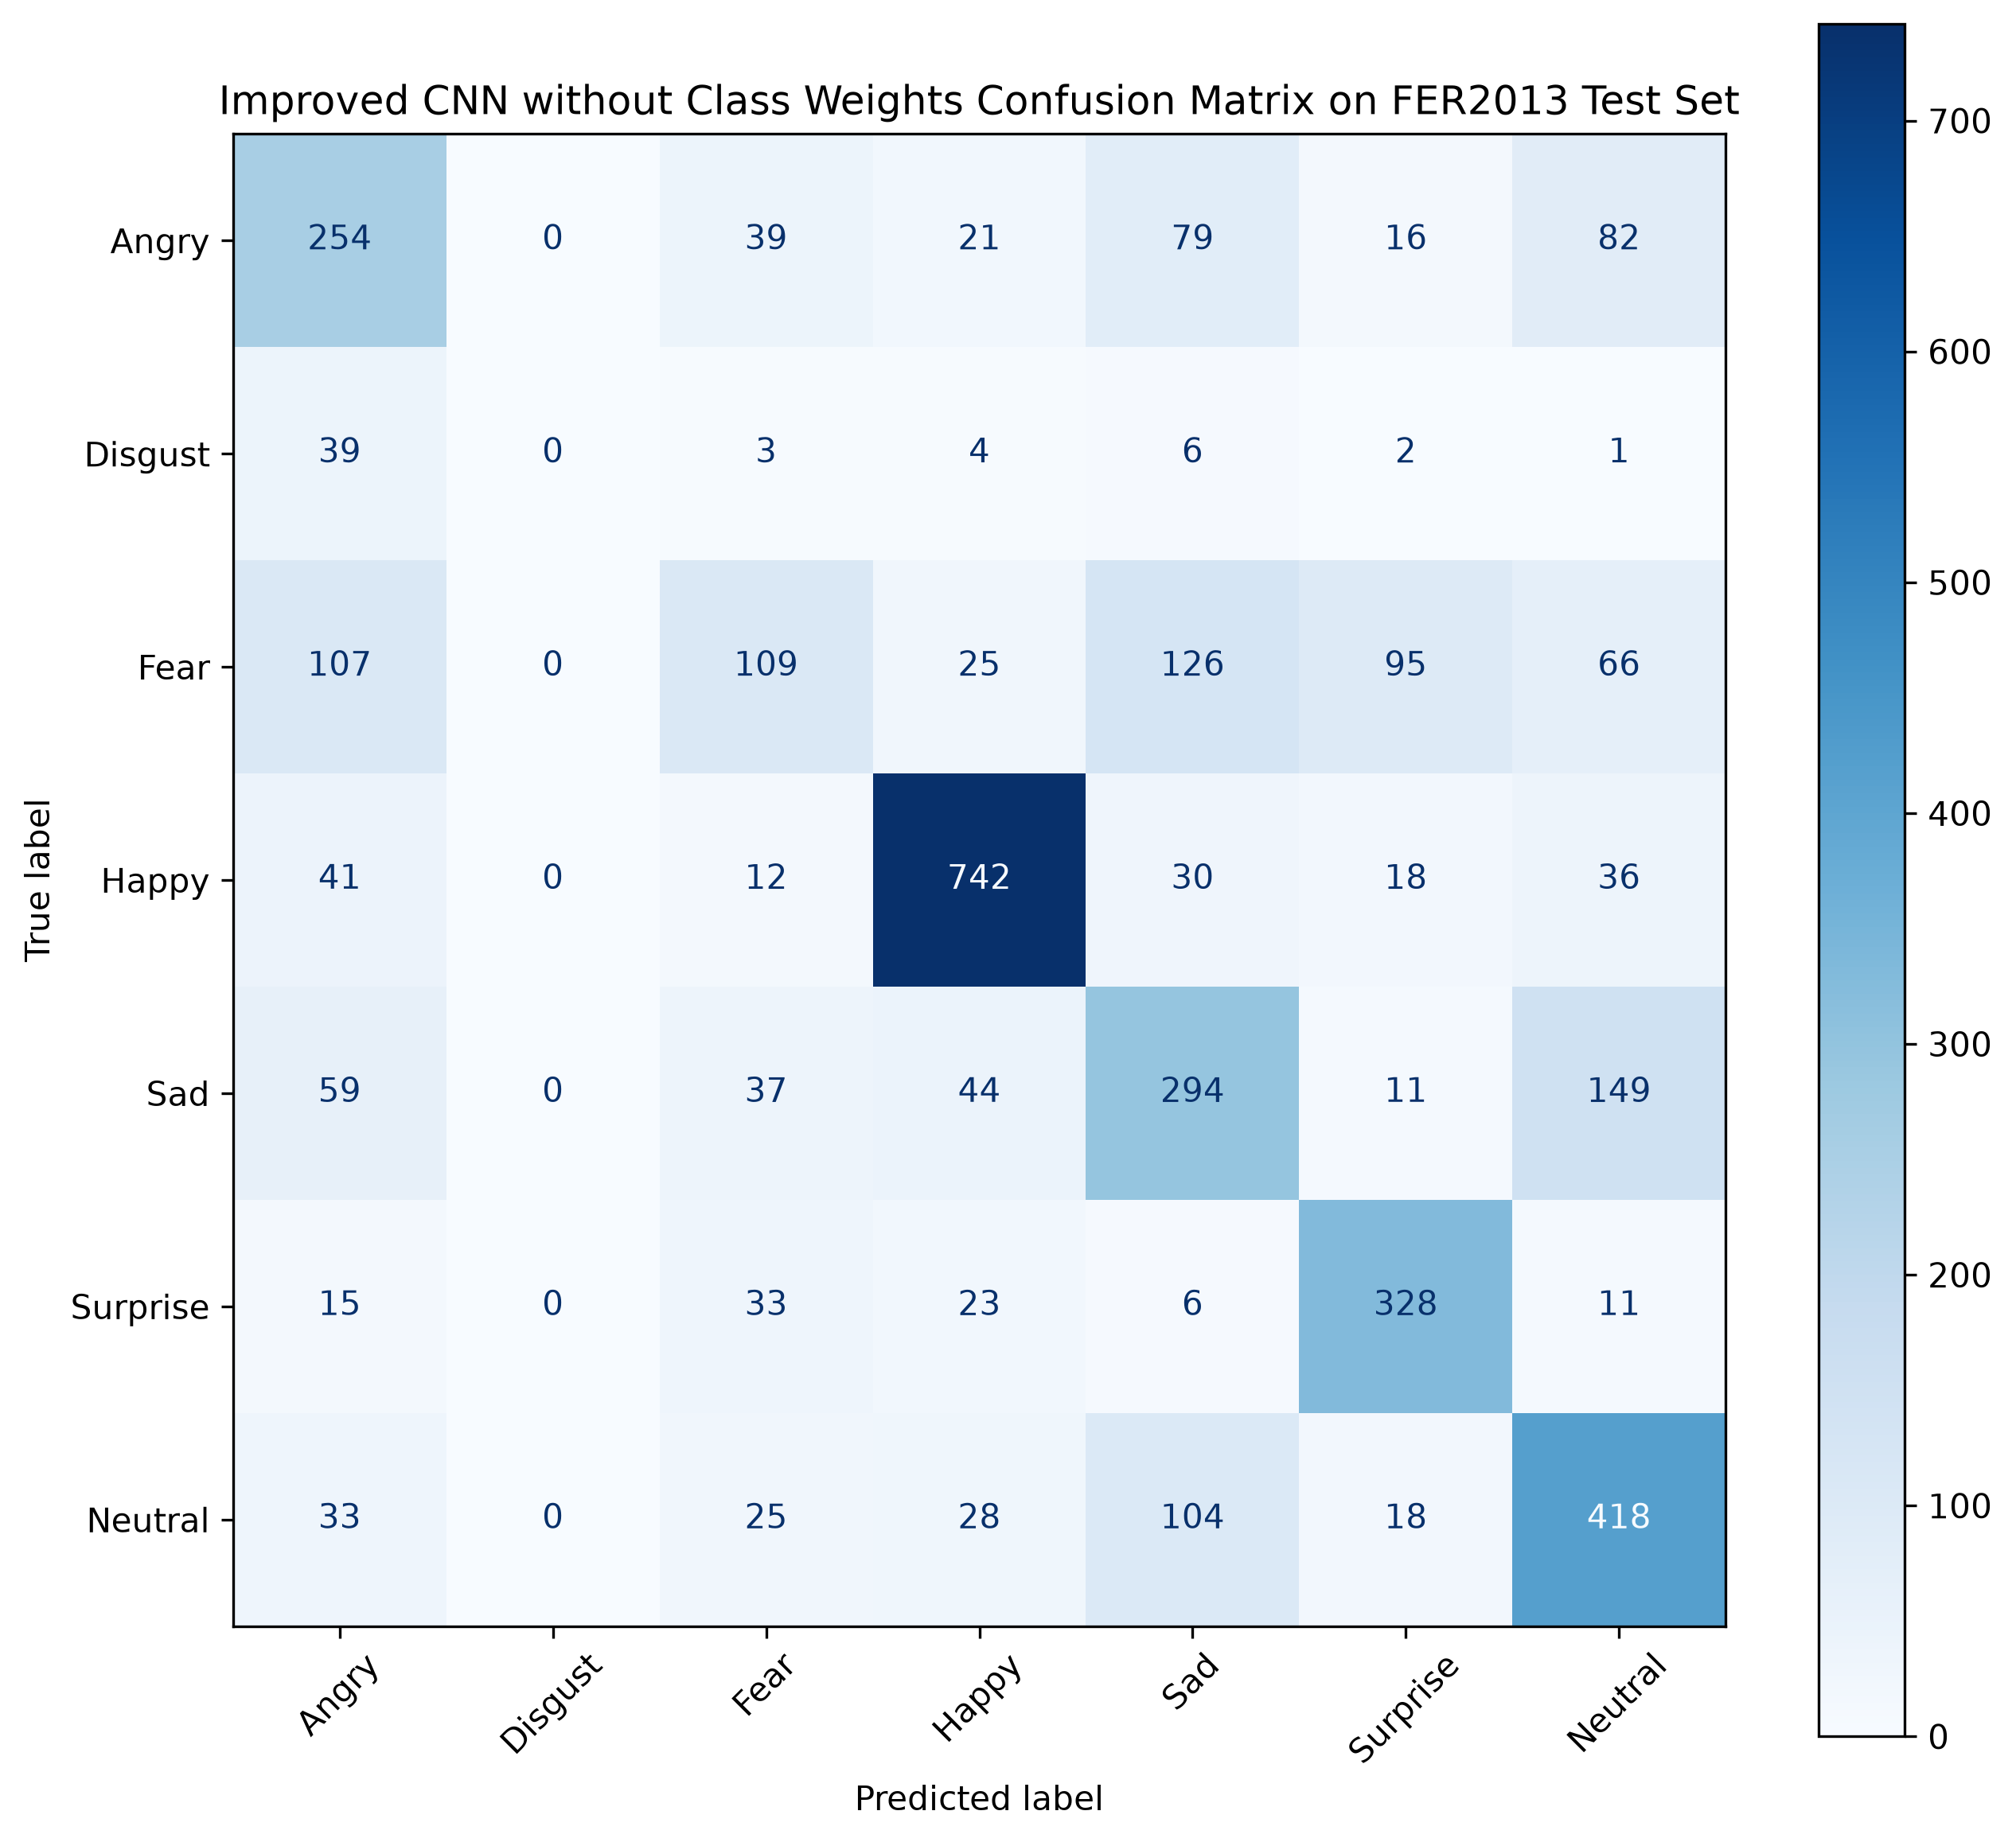

In [16]:
display(Image(filename=str(FIGURES_DIR / 'improved_cnn_no_class_weights_confusion_matrix.png')))

## 12. Interpretation of Results

The comparison reveals an important trade-off.

### Best overall model

The **Improved CNN without class weights** achieves the best test accuracy, weighted F1-score, and test loss. This suggests that the improved architecture and data augmentation helped generalization.

### Best macro-level balance

The **Baseline CNN** achieves the best Macro F1-score. This means the baseline was more balanced across classes, even though it had slightly lower overall accuracy than the best improved model.

### Effect of class weights

The class-weighted improved model increased attention to minority classes, especially `Disgust`, but reduced overall performance. This means class weighting was not universally beneficial in this setup. It improved some minority-class behavior but hurt the global decision boundary.

## 13. Important Finding: Disgust Class

The `Disgust` class is the most difficult class in this experiment.

The class-weighted model improved recall for `Disgust`, but at the cost of lower global performance.

The no-class-weights model achieved the best overall performance, but failed to correctly identify `Disgust`.

This shows that the dataset imbalance problem cannot be solved only by enabling class weights. Future improvements may require:

1. More data for minority classes
2. Targeted augmentation
3. Focal loss
4. Oversampling minority classes
5. Transfer learning
6. Better face alignment and preprocessing

## 14. Final Model Selection

For the next stages of the project, the selected main model is:

## Improved CNN without Class Weights

Reason:

- Highest test accuracy
- Highest weighted F1-score
- Lowest test loss
- Better validation accuracy than the baseline
- Uses a stronger architecture with data augmentation and batch normalization

However, the baseline model remains important because it achieved the best Macro F1-score. Therefore, both results should be discussed in the final report.

## 15. Conclusion

This stage strengthened the project by adding real experimental comparison.

Instead of only training one model, the project now includes:

1. A baseline CNN
2. An improved CNN with class weights
3. An improved CNN without class weights
4. Test-set comparison
5. Classification reports
6. Confusion matrices
7. Training curves
8. A clear ablation-style analysis

### Next Step

The next stage is to implement **confidence threshold analysis**.

This will allow the system to reject low-confidence predictions and output an `Uncertain` class when the model is not reliable enough.

That stage is directly connected to the project extra requirement:

> Add a confidence threshold and neutral/rejection class to reduce false predictions.